# Testing out topological features on the protein binding problem

In this document I try calculating topoligical features for the PDBBind datasets to see if adding them to the features available will make the ML algorithms better. This is really a control for the addition of topology, before we add it to the spherical NNs.

To-Do:
1. make a nice train test train test graph plotter
2. tidy up and move functions into the module
3. get grid fucntionalisation working (fix the environment)
4. figure out how to re-write the standard models 

Thought: we could calc the topological features of the complex? At the moment, it is the protein and ligand separately, which I think is good, as we might well want to screen novel ligands against known protein targets, without first making hte complex.

run Do_PDBBind_topology_features.py to make/remake datasets

In [1]:
# lets load our libraries
#!conda install -y -c conda-forge numpy=1.19.5

from rdkit import Chem
from rdkit.Chem import Draw

from pathlib import Path
import os
import sys
import rdkit
import h5py

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri 
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter


# topology stuff 
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

_base_dir = Path.cwd().parent
_src_dir = str(_base_dir / "src")
if _src_dir not in sys.path:
    sys.path.append(_src_dir)

import MoleculeReader

import tensorflow as tf
print("TensorFlow version: " + tf.__version__)
import deepchem as dc
import helper_functions as h
#from projection.face import Face

Skipped loading some Pytorch utilities, missing a dependency. No module named 'torch'
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!


This module requires PyTorch to be installed.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading some PyTorch models, missing a dependency. No module named 'torch'
No module named 'torch'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'torch'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


TensorFlow version: 2.19.0


In [2]:
from pathlib import Path
base_dir = Path.cwd().resolve().parent
data_dir = base_dir / "datasets" / "PDBBind_v2016_refined"
out_dir  = base_dir / "output"
save_dir = out_dir / "converted"
results_dir = out_dir / "results"

test_file='4q90_pocket.pdb'
test_file_ligand='4q90_ligand.mol2'
test_pdb_code='4q90'
refined_file_name='PDBBind_refined_2016_topological_features.hdf5'
core_file_name = 'PDBBind_core_2016_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset

## Functions

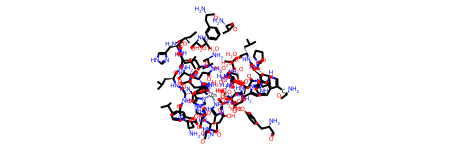

In [3]:
# this should produce a picture of the binding pocket 
# this uses rdkit and gets the original (non-zero centred) positions
test_file_location=os.path.join(data_dir, test_pdb_code, test_file)
mol_orig=rdkit.Chem.rdmolfiles.MolFromPDBFile(test_file_location)
mol_orig

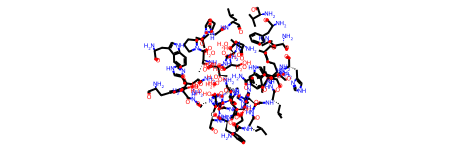

In [4]:
# this uses my code to grab and load the samebinding pocket

mol=MoleculeReader.PDBMolecule(test_file_location)
coords=mol.coords
mol.molecule

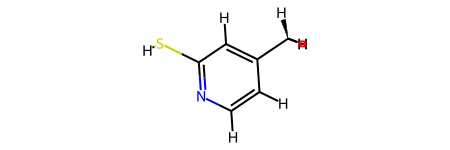

In [5]:
# test with icosahedron project code
# you should see a molecule
test_file_location=os.path.join(data_dir, test_pdb_code, test_file_ligand)
lig=MoleculeReader.Mol2Molecule(test_file_location,
                 sanitize=False)
lig.molecule

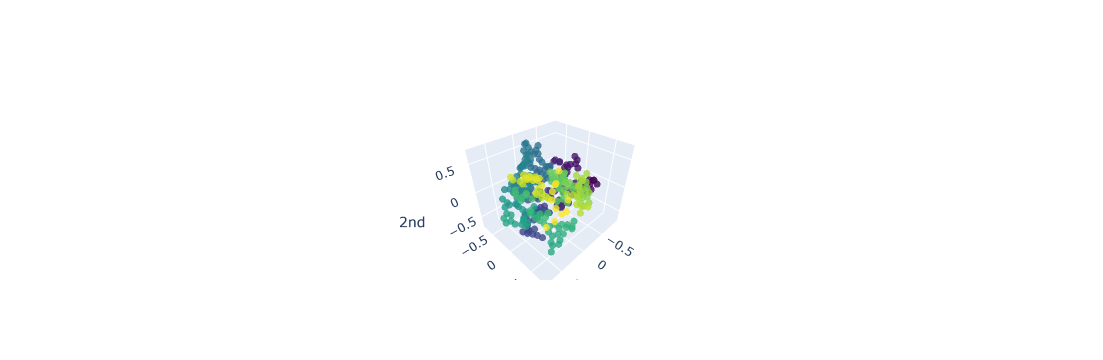

In [6]:
# makes a point cloud version of the structure
# there are no atom types
plot_point_cloud(coords)

### Persistence diagrams

This maps the persistance ofconnected chunks, loops and voids over increasing scale

In [7]:
# Track connected components, loops, and voids
homology_dimensions = [0, 1, 2]

# Collapse edges to speed up H2 persistence calculation!
persistence = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=homology_dimensions,
    n_jobs=6,
    collapse_edges=True,
)
reshaped_coords=coords[None, :, :]
diagrams_basic = persistence.fit_transform(reshaped_coords)

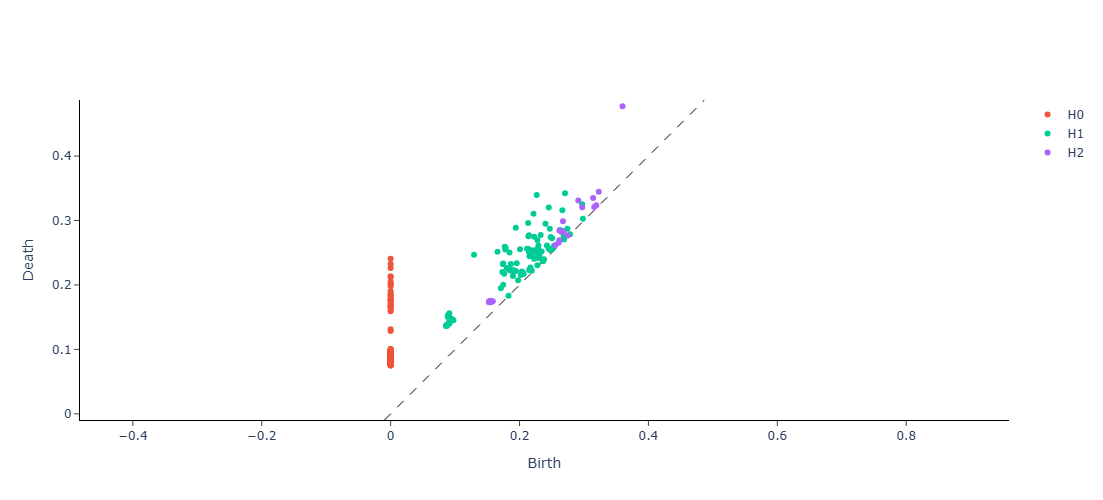

In [8]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

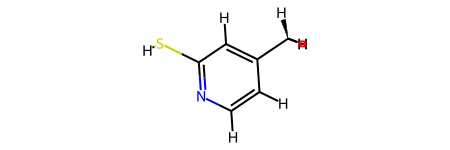

In [9]:
# test with icosahedron project code
# you should see a molecule
# test with icosahedron project code
# you should see a molecule
test_file_location=os.path.join(data_dir, test_pdb_code, test_file_ligand)
lig=MoleculeReader.Mol2Molecule(test_file_location,
                 sanitize=False)
coords_lig=lig.coords
lig.molecule

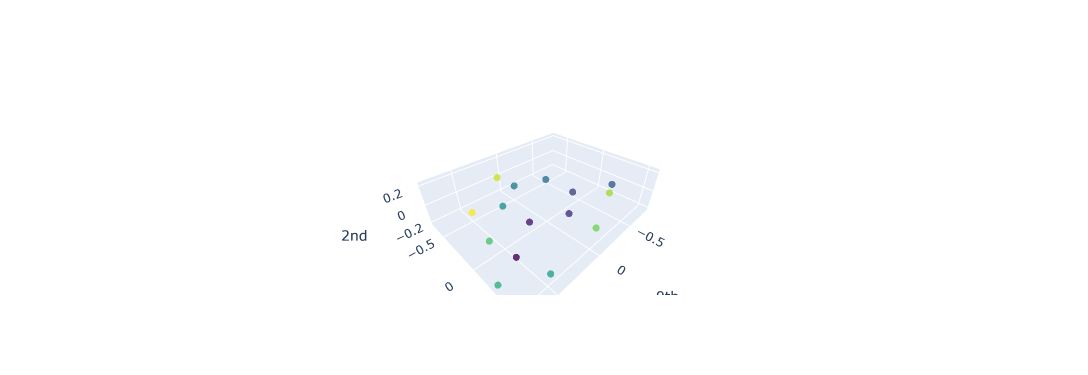

In [10]:
plot_point_cloud(coords_lig)

In [11]:
# Track connected components, loops, and voids
homology_dimensions = [0, 1, 2]

# Collapse edges to speed up H2 persistence calculation!
persistence = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=homology_dimensions,
    n_jobs=6,
    collapse_edges=True,
)
reshaped_coords_lig=coords_lig[None, :, :]
diagrams_basic_lig = persistence.fit_transform(reshaped_coords_lig)

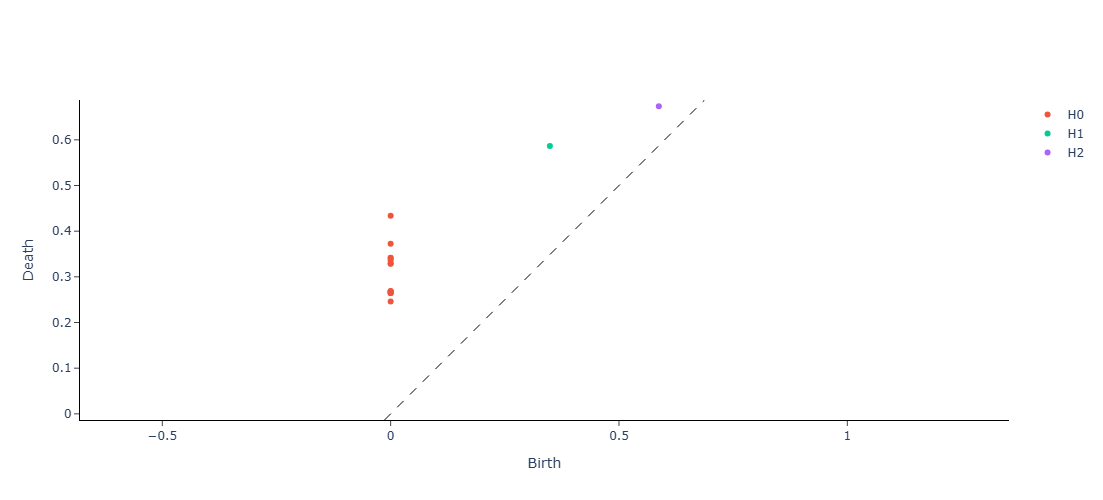

In [12]:
# Circle
plot_diagram(diagrams_basic_lig[0])

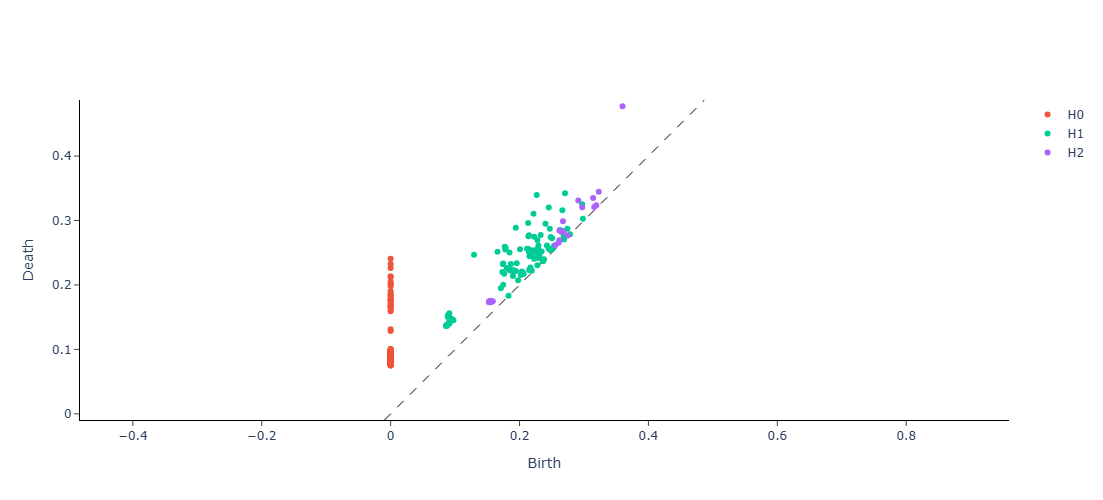

In [13]:
# Circle
plot_diagram(diagrams_basic[0])

In [14]:


persistence_entropy = PersistenceEntropy()

# calculate topological feature matrix
X_basic = persistence_entropy.fit_transform(diagrams_basic)

# expect shape - (n_point_clouds, n_homology_dims)
X_basic.shape

(1, 3)

In [15]:
X_basic

array([[8.20133096, 6.23644948, 3.75009902]])

## Trying to train a classifier on topology features of proteins

In [16]:
def basic_info_hdf5_dataset(hf, label='molID'):
    """Calcs some basic data
    hf is the file handle to hdf5 file
    label is the unique ID label per class/molecule in hte dataset"""
    molID_List_orig = hf['molID']
    num_of_rows = len(molID_List_orig)
    print(f'num_of_ rows is:\t{num_of_rows}')
    counted_molID_List = Counter(molID_List_orig)
    molID_List = [x for x in counted_molID_List.keys()]
    # print(molID_List)
    num_of_molecules = len(molID_List)
    print(f'num_of_molecules is:\t {num_of_molecules}')
    egg = Counter(Counter(molID_List_orig).values())
    if not len(egg.keys()) == 1:
        print('Warning: Unbalanced dataset\nMolID: count')
        print(counted_molID_List)
    else:
        num_of_augments = [x for x in egg.keys()][0]
        print(f'num_of_augments is:\t{num_of_augments}')

In [17]:
#out_file_name="PDBBind_core_topological_features.hdf5"
# Open hdf5 file, calc basic details#
#outfile = out_file_name
fh = h5py.File(str(save_dir / refined_file_name), 'r+')
num_of_rows, num_of_molecules=basic_info_hdf5_dataset(fh, label='molID')
#fh.close()

KeyError: "Unable to synchronously open object (object 'molID' doesn't exist)"

In [ ]:
fh.close()

In [ ]:
len(fh['L_pers_img_3'][:])

In [ ]:
fh['-logKd_over_Ki'][:12]

In [ ]:
fh['ligand_name'][:]

In [ ]:
fh['PDB_code'][:12]

In [ ]:
fh['P_pers_S_1'][:12]

In [ ]:
#out_file_name="core_topological_features.hdf5"
# Open hdf5 file, calc basic details
#outfile = out_file_name
print(core_file_name)
fhcore = h5py.File(os.path.join(save_dir,core_file_name), 'r+')
num_of_rows, num_of_molecules=basic_info_hdf5_dataset(fhcore, label='molID')
#fh.close()

In [ ]:
fhcore.keys()

In [ ]:
fhcore['PDB_code'][:]

In [ ]:
fh['PDB_code'][:]

In [ ]:
fhcore['PDB_code'][:][0] in fh['PDB_code'][:]

In [ ]:
len([fhcore['PDB_code'][:][i] for i in range(195) if fhcore['PDB_code'][:][i] in fh['PDB_code'][:]])

In [ ]:
model = RandomForestRegressor(n_estimators=100)
        model.fit(train_X_data,train_y_data)
        train_scores.append(model.score(train_X_data,train_y_data))

In [ ]:
fh['PDB_code'][:][100]

In [ ]:
fh['-logKd_over_Ki'][:][100]

In [ ]:
fh['P_pers_S_1'][:][100]

In [ ]:
fh["P_no_p_1"][:][1]

In [ ]:
fh['PDB_code'][:][1]

In [ ]:
fh.close()

In [ ]:
fhcore.close()

In [ ]:
115-7

## making the dataset from the hdf5 file

In [ ]:

PDB_List=df_index_core['PDB_code']
num_of_proteins = len(PDB_List)
feature_name_list = ['P_pers_S_1', 'P_pers_S_2', 'P_pers_S_3',
                    'P_no_p_1', 'P_no_p_2', 'P_no_p_3',
                    'P_bottle_1', 'P_bottle_2', 'P_bottle_3',
                    'P_wasser_1', 'P_wasser_2', 'P_wasser_3',
                    'P_landsc_1', 'P_landsc_2', 'P_landsc_3',
                    'P_pers_img_1', 'P_pers_img_2', 'P_pers_img_3',
                    'L_pers_S_1', 'L_pers_S_2', 'L_pers_S_3',
                    'L_no_p_1', 'L_no_p_2', 'L_no_p_3',
                    'L_bottle_1', 'L_bottle_2', 'L_bottle_3',
                    'L_wasser_1', 'L_wasser_2', 'L_wasser_3',
                    'L_landsc_1', 'L_landsc_2', 'L_landsc_3',
                    'L_pers_img_1', 'L_pers_img_2', 'L_pers_img_3'] ## finish this!

dataset = np.zeros((Num_of_proteins, 36))
i=0
for feature_name in feature_name_list:
    dataset[:,i] = fh[feature_name][:]
    i=i+1

topl_PDB_all_core_mat_large=dataset

topl_PDB_all_core_large=dataset.tolist()

topl_PDB_all_core_small = [x[0:3] for x in topl_PDB_all_core_large]
#topl_PDB_all_core_small
topl_PDB_all_core_mat_small = np.array(topl_PDB_all_core_small)
#topl_PDB_all_core_mat_small

X_data_large = topl_PDB_all_core_mat_large
X_data_small = topl_PDB_all_core_mat_small
Num_of_proteins = len(X_data_large)

y_dataset=np.zeros((Num_of_proteins, 2))
i=0
for feature_name in ["-logKd_over_Ki","-logKd_over_Ki"]:
    y_dataset[:,i] = fh[feature_name][:]
    i=i+1

#y_data = fh["-logKd_over_Ki"][:].tolist()

from sklearn.decomposition import PCA
pca = PCA(n_components=36)
principalComponents_large = pca.fit_transform(topl_PDB_all_core_large)

In [ ]:
num_of_proteins = len(X_data)
print(num_of_proteins)
num_of_repeats = 10
test_set_size = int(num_of_proteins*0.1)
validation_set_size = int(num_of_proteins*0.1)
print(test_set_size)

X_data

In [ ]:
train_scores=[1.84,1.711,1.833]
validate_scores=[1.93,1.717,1.812]
test_scores=[2.009,1.95,1.9987]

h.nice_stats_outputter(train_scores, test_scores, validate_scores)

# Running ML on the data

## Random forest benchmark

In [ ]:
y_data

In [ ]:
## To-Do implement RMSE
def run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=int(num_of_proteins*0.1)):
    
    num_of_proteins = len(X_data)

    train_scores=[]
    test_scores=[]

    for trail in range(num_of_repeats):
        # this sets up the indices for train/test/validate
        (train_X_data, 
         train_y_data, 
         test_X_data, 
         test_y_data, 
         validate_X_data, 
         validate_y_data) = h.set_up_train_test_validate(
            X_data, 
            y_data,
            test_set_size=test_set_size,
            validate_set_size=validate_set_size)
        model = RandomForestRegressor(n_estimators=num_of_estimators)
        model.fit(train_X_data,train_y_data)
        train_scores.append(model.score(train_X_data,train_y_data))
        test_scores.append(model.score(test_X_data,test_y_data))

    return (train_scores,test_scores)



In [ ]:
df_data_core['-logKd/Ki']

In [ ]:
# does repeated RF experiments
#y_data=df_cluster_core['-logKd/Ki']
X_data = X_data_large

(train_scores,test_scores)=run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=int(num_of_proteins*0.3),
    validate_set_size=0)

out=h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')
(min_train_RF_large, mean_train_RF_large, std_error_train_RF_large, max_train_RF_large,
                min_test_RF_large, mean_test_RF_large, std_error_test_RF_large, max_test_RF_large)=out
RF_large_train_scores=train_scores
RF_large_test_scores=test_scores

In [ ]:
# does repeated RF experiments
y_data=df_data_refined['-logKd/Ki']
#X_data = X_data_small

(train_scores,test_scores)=run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=0)

out=h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')
(min_train_RF_small, mean_train_RF_small, std_error_train_RF_small, max_train_RF_small,
                min_test_RF_small, mean_test_RF_small, std_error_test_RF_small, max_test_RF_small)=out
RF_small_train_scores=train_scores
RF_small_test_scores=test_scores

In [ ]:
x_positions = [1,2,3,4]
means=[mean_train_RF_small, mean_test_RF_small, mean_train_RF_large, mean_test_RF_large]
stds=[std_error_test_RF_small, std_error_test_RF_small, std_error_train_RF_large, std_error_test_RF_large]

plt.figure(figsize=(16, 9))

plt.bar(x_positions, means, color=["b","r","b","r"], yerr=stds, capsize=10)
x=RF_small_train_scores; plt.plot(np.ones(len(x)),x,'o')
x=RF_small_test_scores; plt.plot(2*np.ones(len(x)),x,'o')
x=RF_large_train_scores; plt.plot(3*np.ones(len(x)),x,'o')
x=RF_large_test_scores; plt.plot(4*np.ones(len(x)),x,'o')
plt.savefig("RF.png")

## simple NN

In [ ]:
np.floor(0.05*Num_of_proteins)

### Trains a series of NN models for some representative stats

### Keras NN

In [ ]:

num_of_proteins = Num_of_proteins
def run_repeated_keras_NN_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_epochs=100,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=int(num_of_proteins*0.1)):

    num_of_proteins = len(X_data)

    train_scores_r2=[]
    test_scores_r2=[]
    train_scores_rmse=[]
    test_scores_rmse=[]

    for trial in range(num_of_repeats):
        (train_X_data, 
         train_y_data, 
         test_X_data, 
         test_y_data, 
         validate_X_data, 
         validate_y_data) = h.set_up_train_test_validate(
            X_data, 
            y_data,
            test_set_size=test_set_size,
            validate_set_size=validate_set_size,
            verbose=True)
        # put data into a dataset for input to keras
        train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
        test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
        # choose metric(s)
        metric1 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
        metric2 = dc.metrics.Metric(dc.metrics.rms_score)
        # make deepchem model from keras model
        model = dc.models.KerasModel(keras_model, dc.models.losses.L2Loss())
        # fit it
        model.fit(train_dataset, nb_epoch=number_of_epochs)
        train_score = model.evaluate(train_dataset, [metric1, metric2])
        test_score = model.evaluate(test_dataset, [metric1, metric2])
        train_score_r2 = train_score['pearson_r2_score']
        test_score_r2 = test_score['pearson_r2_score']
        train_score_rmse = train_score['rms_score']
        test_score_rmse = test_score['rms_score']
        print('R2 error\ttrain {:.3}, \t test: {:.3}'.format(train_score_r2, test_score_r2))
        print('RMSE error\ttrain {:.3}, \t test: {:.3}'.format(train_score_rmse, test_score_rmse))
        train_scores_r2.append(train_score_r2)
        test_scores_r2.append(test_score_r2)
        train_scores_rmse.append(train_score_rmse)
        test_scores_rmse.append(test_score_rmse)

    print(train_scores_r2)
    print(test_scores_r2)
    out=(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse)
    return out
    


In [ ]:
y_data_new = y_data
y_data = fh["-logKd_over_Ki"]
print(y_data)
y_dataset[:,0]
#y_task = y_true[:, task]

In [ ]:
y_data.shape

In [ ]:
y_data_2 = np.reshape(y_data,(-1,1))
y_data_2.shape

In [ ]:
train_dataset.X

In [ ]:
y_data_2 = 
(train_X_data, 
         train_y_data, 
         test_X_data, 
         test_y_data, 
         validate_X_data, 
         validate_y_data) = h.set_up_train_test_validate(
            X_data, 
            y_data,
            test_set_size=19,
            validate_set_size=19,
            verbose=True)
train_y_data=y_dataset[:,0]

if True:
        train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
        test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
        # choose metric(s)
        metric1 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
        metric2 = dc.metrics.Metric(dc.metrics.rms_score)
        # make deepchem model from keras model
        model = dc.models.KerasModel(keras_model, dc.models.losses.L2Loss())
        # fit it
        model.fit(train_dataset, nb_epoch=number_of_epochs)
        train_score = model.evaluate(train_dataset, [metric1, metric2])
        test_score = model.evaluate(test_dataset, [metric1, metric2])
        train_score_r2 = train_score['pearson_r2_score']
        test_score_r2 = test_score['pearson_r2_score']
        train_score_rmse = train_score['rms_score']
        test_score_rmse = test_score['rms_score']
        print('R2 error\ttrain {:.3}, \t test: {:.3}'.format(train_score_r2, test_score_r2))
        print('RMSE error\ttrain {:.3}, \t test: {:.3}'.format(train_score_rmse, test_score_rmse))
        train_scores_r2.append(train_score_r2)
        test_scores_r2.append(test_score_r2)
        train_scores_rmse.append(train_score_rmse)
        test_scores_rmse.append(test_score_rmse)


In [ ]:
# does repeated keras NN experiments
#y_data=df_data_refined['-logKd/Ki']
y_data=df_data_core['-logKd/Ki']
X_data = X_data_small
number_of_epochs=100

# make a model for use
keras_model = tf.keras.Sequential([
        tf.keras.layers.Dense(1000, activation='relu'),
        tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(500, activation='relu'),
        tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(500, activation='relu'),
        tf.keras.layers.Dropout(rate=0.3),
        tf.keras.layers.Dense(500, activation='relu'),
        #tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(200, activation='relu'),
        #tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(1)
    ])

out=run_repeated_keras_NN_tests(
    X_data,
    y_data,
    num_of_repeats=5,
    num_of_epochs=100,
    test_set_size=int(Num_of_proteins*0.1),
    validate_set_size=int(Num_of_proteins*0.1))

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

R2 error	train 0.0374, 	 test: 0.0133
RMSE error	train 2.22, 	 test: 2.09
[0.00862413656259321, 0.03899378450766216, 0.042426376815455386, 0.05189112803408881, 0.0374447683433612]
[0.25280690760999414, 0.12726939792810577, 0.014591164756026606, 0.2567764053462631, 0.013264762709341148]


In [ ]:
print('\t\tR2 results')
out_r2 = h.nice_stats_outputter(train_scores_r2, test_scores_r2)
print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores_rmse, test_scores_rmse)


(min_train_K_NN_small_r2, mean_train_K_NN_small_r2, std_error_train_K_NN_small_r2, max_train_K_NN_small_r2,
                min_test_K_NN_small_r2, mean_test_K_NN_small_r2, std_error_test_K_NN_small_r2, max_test_K_NN_small_r2)=out_r2

K_NN_small_train_scores_r2 = train_scores_r2
K_NN_small_test_scores_r2 = test_scores_r2


(min_train_K_NN_small_rmse, mean_train_K_NN_small_rmse, std_error_train_K_NN_small_rmse, max_train_K_NN_small_rmse,
                min_test_K_NN_small_rmse, mean_test_K_NN_small_rmse, std_error_test_K_NN_small_rmse, max_test_K_NN_small_rmse)=out_rmse

K_NN_small_train_scores_rmse = train_scores_rmse
K_NN_small_test_scores_rmse = test_scores_rmse

### keras model with larger dataset (18 features)

In [ ]:
# does repeated keras NN experiments
y_data=df_cluster_core['-logKd/Ki']
X_data = X_data_large
test_set_size=6
number_of_epochs=3000

if True:
# make a model for use
    keras_model = tf.keras.Sequential([
        tf.keras.layers.Dense(1000, activation='relu'),
        tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(500, activation='relu'),
        tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(500, activation='relu'),
        tf.keras.layers.Dropout(rate=0.3),
        tf.keras.layers.Dense(500, activation='relu'),
        #tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(200, activation='relu'),
        #tf.keras.layers.Dropout(rate=0.5),
        tf.keras.layers.Dense(1)
    ])

out=run_repeated_keras_NN_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_epochs=100,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=0)

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

R2 error	train 0.682, 	 test: 0.268
RMSE error	train 2.47, 	 test: 2.64
Test set indices:
[117 156   5 125 122   4 151 185  71  95 136  13  17 127  29  55 112 182
  24]
Validation set indices:
[]
R2 error	train 0.708, 	 test: 0.0349
RMSE error	train 2.45, 	 test: 4.01
Test set indices:
[175  66  28  93 139  61   2 146 191 122  81  56   9 192 144  64 158  36
 125]
Validation set indices:
[]
R2 error	train 0.681, 	 test: 0.478
RMSE error	train 2.3, 	 test: 2.47
Test set indices:
[161  34  24  47  63 143  92  37 168 113  49 160 105  97  68 155 121  21
 185]
Validation set indices:
[]
R2 error	train 0.669, 	 test: 0.35
RMSE error	train 2.51, 	 test: 2.79
Test set indices:
[ 65  86  12 114 106 155  70  35 113  38   5  50  94 168 147  96 101 123
  36]
Validation set indices:
[]


R2 error	train 0.556, 	 test: 0.688
RMSE error	train 2.53, 	 test: 2.78
Test set indices:
[ 77  46 135  89  12 172   4 164  43 174  88  26 139 121 163  60 106  50
 186]
Validation set indices:
[]
R2 error	train 0.566, 	 test: 0.413
RMSE error	train 2.58, 	 test: 2.54
Test set indices:
[140  37 184 151 127 122 132 121 101  51 124  10  21 119 171 105  45   5
  16]
Validation set indices:
[]
R2 error	train 0.671, 	 test: 0.386
RMSE error	train 2.53, 	 test: 3.19
[0.544487451777089, 0.6391938266361998, 0.6385252706670641, 0.681533067906199, 0.7084711149076114, 0.6812934812308176, 0.6692987814765639, 0.555752034241656, 0.5662022074034, 0.670663581837591]
[0.0982138955172375, 0.1728538302382835, 0.20626634407296016, 0.2684785912104858, 0.034885469093297955, 0.47753434237774384, 0.3501034728161483, 0.6882628120881058, 0.4129385603677149, 0.3857258208089301]


In [ ]:
print('\t\tR2 results')
out_r2 = h.nice_stats_outputter(train_scores_r2, test_scores_r2)
print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores_rmse, test_scores_rmse)


(min_train_K_NN_large_r2, mean_train_K_NN_large_r2, std_error_train_K_NN_large_r2, max_train_K_NN_large_r2,
                min_test_K_NN_large_r2, mean_test_K_NN_large_r2, std_error_test_K_NN_large_r2, max_test_K_NN_large_r2)=out_r2

K_NN_large_train_scores_r2 = train_scores_r2
K_NN_large_test_scores_r2 = test_scores_r2


(min_train_K_NN_large_rmse, mean_train_K_NN_large_rmse, std_error_train_K_NN_large_rmse, max_train_K_NN_large_rmse,
                min_test_K_NN_large_rmse, mean_test_K_NN_large_rmse, std_error_test_K_NN_large_rmse, max_test_K_NN_large_rmse)=out_rmse

K_NN_large_train_scores_rmse = train_scores_rmse
K_NN_large_test_scores_rmse = test_scores_rmse

In [ ]:
x_positions = [1,2,3,4]
means=[mean_train_K_NN_small_r2, mean_test_K_NN_small_r2, mean_train_K_NN_large_r2, mean_test_K_NN_large_r2]
stds=[std_error_train_K_NN_small_r2, std_error_test_K_NN_small_r2, std_error_train_K_NN_large_r2, std_error_test_K_NN_large_r2]

plt.figure(figsize=(16, 9))

plt.bar(x_positions, means, color=["b","r","b","r"], yerr=stds, capsize=10)
x=K_NN_small_train_scores_r2; plt.plot(np.ones(len(x)),x,'o')
x=K_NN_small_test_scores_r2; plt.plot(2*np.ones(len(x)),x,'o')
x=K_NN_large_train_scores_r2; plt.plot(3*np.ones(len(x)),x,'o')
x=K_NN_large_test_scores_r2; plt.plot(4*np.ones(len(x)),x,'o')
plt.savefig("keras_NN_r2.png")

In [ ]:
x_positions = [1,2,3,4]
means=[mean_train_K_NN_small_rmse, mean_test_K_NN_small_rmse, mean_train_K_NN_large_rmse, mean_test_K_NN_large_rmse]
stds=[std_error_train_K_NN_small_rmse, std_error_test_K_NN_small_rmse, std_error_train_K_NN_large_rmse, std_error_test_K_NN_large_rmse]

plt.figure(figsize=(16, 9))

plt.bar(x_positions, means, color=["b","r","b","r"], yerr=stds, capsize=10)
plt.plot([0.5,4.5],[2,2])
x=K_NN_small_train_scores_rmse; plt.plot(np.ones(len(x)),x,'o')
x=K_NN_small_test_scores_rmse; plt.plot(2*np.ones(len(x)),x,'o')
x=K_NN_large_train_scores_rmse; plt.plot(3*np.ones(len(x)),x,'o')
x=K_NN_large_test_scores_rmse; plt.plot(4*np.ones(len(x)),x,'o')
plt.savefig("keras_NN_RMSE.png")

### dc multitask regressor model

In [ ]:


def run_repeated_dc_multitask_regressor_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_epochs=3000,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=int(num_of_proteins*0.1)):

    num_of_proteins = len(X_data)


    train_scores_r2=[]
    test_scores_r2=[]
    train_scores_rmse=[]
    test_scores_rmse=[]

    for trial in range(num_of_repeats):
        (train_X_data, train_y_data, test_X_data, test_y_data, validate_X_data, validate_y_data) = h.set_up_train_test_validate(
            X_data, 
            y_data,
            test_set_size=test_set_size,
            validate_set_size=0,
            verbose=True)
        # put data into a dataset for input to keras
        train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
        test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
        n_features=train_dataset.X.shape[1]
        # choose metric(s)
        metric1 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
        metric2 = dc.metrics.Metric(dc.metrics.rms_score)
        # make deepchem model from keras model
        model = dc.models.MultitaskRegressor(
        n_tasks=1,
        n_features=n_features,
        layersizes=[2000,1000],
        dropouts=0.5,
        learning_rate=0.0003)

        model.fit(train_dataset, nb_epoch=number_of_epochs)

        train_score = model.evaluate(train_dataset, [metric1, metric2])
        test_score = model.evaluate(test_dataset, [metric1, metric2])
        train_score_r2 = train_score['pearson_r2_score']
        test_score_r2 = test_score['pearson_r2_score']
        train_score_rmse = train_score['rms_score']
        test_score_rmse = test_score['rms_score']
        print('R2 error\ttrain {:.3}, \t test: {:.3}'.format(train_score_r2, test_score_r2))
        print('RMSE error\ttrain {:.3}, \t test: {:.3}'.format(train_score_rmse, test_score_rmse))
        train_scores_r2.append(train_score_r2)
        test_scores_r2.append(test_score_r2)
        train_scores_rmse.append(train_score_rmse)
        test_scores_rmse.append(test_score_rmse)

    print(train_scores_r2)
    print(test_scores_r2)
    out=(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse)
    return out
    


In [ ]:
# running the standard dc NN model

# does repeated keras NN experiments
y_data=df_cluster_core['-logKd/Ki']
X_data = X_data_small
number_of_epochs=1500

out=run_repeated_dc_multitask_regressor_tests(
    X_data,
    y_data,
    num_of_repeats=50,
    num_of_epochs=number_of_epochs,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=test_set_size)

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

R2 error	train 0.0921, 	 test: 0.0823
RMSE error	train 2.17, 	 test: 2.01
Test set indices:
[134 136  46  42  82  76 189 152 106   2  30  64  59  29 115  96 158  89
 171]
Validation set indices:
[]
R2 error	train 0.0854, 	 test: 0.253
RMSE error	train 2.15, 	 test: 2.24
Test set indices:
[159  29  23 104 184   7  21  62  91  87  54 136  41 100 155  97  59  32
  61]
Validation set indices:
[]
R2 error	train 0.0927, 	 test: 0.0508
RMSE error	train 2.14, 	 test: 2.23
Test set indices:
[ 97 122  65 169  33 140  51   8  40  26 133 113  53 131  28  20  16  77
  60]
Validation set indices:
[]
R2 error	train 0.0925, 	 test: 0.0833
RMSE error	train 2.17, 	 test: 2.0
Test set indices:
[ 44   1 179 177 103 187  46 164  43  80  53  60 182  12  67 143  97  42
   0]
Validation set indices:
[]


R2 error	train 0.0975, 	 test: 0.0245
RMSE error	train 2.16, 	 test: 2.01
Test set indices:
[ 43  69  93  72 124  21 159 176 192  45  82 163 113   6 102  42  15 132
 116]
Validation set indices:
[]
R2 error	train 0.108, 	 test: 0.0261
RMSE error	train 2.11, 	 test: 2.6
Test set indices:
[ 87 118 174 110  42 147  89 123 161  59 193 169 170  51  64   6 179 162
 127]
Validation set indices:
[]
R2 error	train 0.117, 	 test: 0.0119
RMSE error	train 2.11, 	 test: 2.43
Test set indices:
[110 158 190 131  63 162 167 170 194  84 103 132 125  98  92 118  82 175
  25]
Validation set indices:
[]


R2 error	train 0.107, 	 test: 0.0216
RMSE error	train 2.12, 	 test: 2.38
Test set indices:
[141 169 111  43 134 183 104  58 174 146  77  39  28 158  88 150  87   2
  66]
Validation set indices:
[]
R2 error	train 0.0922, 	 test: 0.0781
RMSE error	train 2.16, 	 test: 2.11
Test set indices:
[ 26  32  49 160  65 171 110 157 148  53  10 176 133   6  90 131  44  22
 184]
Validation set indices:
[]
R2 error	train 0.0907, 	 test: 0.0598
RMSE error	train 2.18, 	 test: 1.83
Test set indices:
[169 114  63  44 153   3  98   5  46  47  50 121  11  70  93 129 109 141
 113]
Validation set indices:
[]
R2 error	train 0.0831, 	 test: 0.211
RMSE error	train 2.17, 	 test: 2.07
Test set indices:
[ 45  64 115 150  32 142  62  18  15  10  81 105 152  96  16 189 130 120
 183]
Validation set indices:
[]


R2 error	train 0.09, 	 test: 0.216
RMSE error	train 2.19, 	 test: 1.85
Test set indices:
[ 77  63  64  60 126 166  62   9  52 152  86 176  27  50  42  95 105  94
  56]
Validation set indices:
[]
R2 error	train 0.0887, 	 test: 0.124
RMSE error	train 2.13, 	 test: 2.41
Test set indices:
[159  23  95   4 163 129 156  37 184 186  30   7  71  14  32 194  60 103
 183]
Validation set indices:
[]
R2 error	train 0.103, 	 test: 0.0229
RMSE error	train 2.13, 	 test: 2.3
Test set indices:
[145  91  20   9 121 120 126  66  35  90   7  98 125 183 109  42   1 177
 110]
Validation set indices:
[]
R2 error	train 0.0821, 	 test: 0.215
RMSE error	train 2.14, 	 test: 2.27
Test set indices:
[162 133 161  25  14 108 102 182 126  16 130 157  86  89 163  52 175 153
 121]
Validation set indices:
[]


R2 error	train 0.0953, 	 test: 0.0787
RMSE error	train 2.14, 	 test: 2.28
Test set indices:
[186  57  38  48 130  92  28  64   7  20  27  94 131 151 191 123  12 159
  24]
Validation set indices:
[]
R2 error	train 0.0887, 	 test: 0.178
RMSE error	train 2.17, 	 test: 2.03
Test set indices:
[113  41 153   5  78  53 166 159 138  74  28  58 104 171  15 102 150 179
 116]
Validation set indices:
[]
R2 error	train 0.0848, 	 test: 0.156
RMSE error	train 2.13, 	 test: 2.42
Test set indices:
[106 127 136  99 184  82 131 173 125  22  69  34  32  97  29  83  92 157
 160]
Validation set indices:
[]


...

R2 error	train 0.0784, 	 test: 0.173
RMSE error	train 2.12, 	 test: 2.56
Test set indices:
[122 165 141  12  36  79  74 135 187  71 143 173  70 107  35  17 147 115
  62]
Validation set indices:
[]
R2 error	train 0.078, 	 test: 0.243
RMSE error	train 2.08, 	 test: 2.85
Test set indices:
[185 143 104  72 174 150  58  64  13  92  66 101 133  69   1 110 122  97
  99]
Validation set indices:
[]
R2 error	train 0.0957, 	 test: 0.117
RMSE error	train 2.09, 	 test: 2.65
Test set indices:
[183  49  12  74 194 101 111  76  31  30 168  66  87   7 102 159 139  26
 190]
Validation set indices:
[]
R2 error	train 0.107, 	 test: 0.0026
RMSE error	train 2.13, 	 test: 2.28
Test set indices:
[189  59 183  11 117 152 113 132 120 122  28 190  98 112  80  10 111 134
  13]
Validation set indices:
[]


R2 error	train 0.0901, 	 test: 0.0178
RMSE error	train 2.15, 	 test: 2.12
Test set indices:
[183   5 105  43  18 161 146 135  80 132 118  94 145 151 143  56 150 187
 169]
Validation set indices:
[]
R2 error	train 0.0962, 	 test: 0.0262
RMSE error	train 2.19, 	 test: 1.78
Test set indices:
[  8  37 187 193  66  68  45  50 163 173  89  44  80  42  56 178 181  43
 125]
Validation set indices:
[]
R2 error	train 0.0742, 	 test: 0.333
RMSE error	train 2.16, 	 test: 2.21
Test set indices:
[188  40  18  72 117  90  46 178 136 186 147  64  25 155   4  65   1  71
  29]
Validation set indices:
[]
R2 error	train 0.0866, 	 test: 0.228
RMSE error	train 2.22, 	 test: 1.42
Test set indices:
[115 137 129 169  29 107 176  41 186 173 105 134  54 126 104  13 118 109
  31]
Validation set indices:
[]


R2 error	train 0.0795, 	 test: 0.256
RMSE error	train 2.13, 	 test: 2.45
Test set indices:
[ 44  21  88 180  86  50  85 154  82 131 108  33 116  77  92  39  68 117
 113]
Validation set indices:
[]
R2 error	train 0.0909, 	 test: 0.105
RMSE error	train 2.18, 	 test: 1.89
Test set indices:
[ 83  89 130 138 151  14 176 186  44  57 164 158  26   6  24 180 111  94
  67]
Validation set indices:
[]
R2 error	train 0.0994, 	 test: 0.0111
RMSE error	train 2.2, 	 test: 1.59
Test set indices:
[159  86 115  55  48 189  79  80 160  62  61 130 146 113  37  46  17  88
 127]
Validation set indices:
[]


R2 error	train 0.088, 	 test: 0.171
RMSE error	train 2.19, 	 test: 1.85
Test set indices:
[134  68   1  59  71 107  36 117 189   8  11  78 190  86 104  51  65  18
  84]
Validation set indices:
[]
R2 error	train 0.105, 	 test: 0.0525
RMSE error	train 2.13, 	 test: 2.35
Test set indices:
[ 16 135  58 183 106   7 100  91 144  95 103  74  29 110  35  82  36  98
 154]
Validation set indices:
[]
R2 error	train 0.0854, 	 test: 0.116
RMSE error	train 2.16, 	 test: 2.13
Test set indices:
[119 179 130 128 194  83  35  16 164  13 161  22  69  12 109 178 104  47
 187]
Validation set indices:
[]
R2 error	train 0.103, 	 test: 0.0155
RMSE error	train 2.18, 	 test: 1.8
Test set indices:
[173  70 158  49 118 163 126  69  23 149  59  50 141 179 123 188 142 161
  90]
Validation set indices:
[]


R2 error	train 0.0796, 	 test: 0.339
RMSE error	train 2.12, 	 test: 2.48
Test set indices:
[142  83   3   7  56  99   0  29 182 116  69  20  38 115 118  68   5  42
 177]
Validation set indices:
[]
R2 error	train 0.0975, 	 test: 0.0528
RMSE error	train 2.13, 	 test: 2.34
Test set indices:
[188  90  35 164  88 125  87  28  63 133 163  68  83  32 106 172  62  86
  48]
Validation set indices:
[]
R2 error	train 0.0813, 	 test: 0.211
RMSE error	train 2.18, 	 test: 1.94
[0.08253120785608278, 0.0967828851521208, 0.07980651176669094, 0.09208735123400574, 0.08544119005693948, 0.09271675716533466, 0.0925129727051297, 0.09745301788901421, 0.10785927931188807, 0.11692750714470092, 0.10729165969496576, 0.09221513411145914, 0.09074016769415565, 0.08313195991322461, 0.09004839506685347, 0.08872479340441501, 0.10287279211826209, 0.08209651190879118, 0.09525668496152755, 0.08874373493335481, 0.08481603568849788, 0.07550130397854402, 0.10030784583737445, 0.08810367723724301, 0.0825431785193263, 0.0778808

In [ ]:
print('\t\tR2 results')
out_r2 = h.nice_stats_outputter(train_scores_r2, test_scores_r2)
print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores_rmse, test_scores_rmse)


(min_train_dc_NN_MR_small_r2, mean_train_dc_NN_MR_small_r2, std_error_train_dc_NN_MR_small_r2, max_train_dc_NN_MR_small_r2,
                min_test_dc_NN_MR_small_r2, mean_test_dc_NN_MR_small_r2, std_error_test_dc_NN_MR_small_r2, max_test_dc_NN_MR_small_r2)=out_r2

dc_NN_MR_small_train_scores_r2 = train_scores_r2
dc_NN_MR_small_test_scores_r2 = test_scores_r2

(min_train_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_small_rmse, max_train_dc_NN_MR_small_rmse,
                min_test_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, max_test_dc_NN_MR_small_rmse)=out_rmse

dc_NN_MR_small_train_scores_rmse = train_scores_rmse
dc_NN_MR_small_test_scores_rmse = test_scores_rmse

In [ ]:
# running the standard dc NN model

# does repeated keras NN experiments
y_data=df_cluster_core['-logKd/Ki']
X_data = X_data_large
number_of_epochs=1500

out=run_repeated_dc_multitask_regressor_tests(
    X_data,
    y_data,
    num_of_repeats=50,
    num_of_epochs=number_of_epochs,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=int(num_of_proteins*0.1))

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

R2 error	train 0.518, 	 test: 0.271
RMSE error	train 1.6, 	 test: 1.76
Test set indices:
[ 65  14 168  27 180  38 164 184 146  61 145  23 133 132  99  64 163  35
 172]
Validation set indices:
[]
R2 error	train 0.477, 	 test: 0.201
RMSE error	train 1.65, 	 test: 1.77
Test set indices:
[157 115 143 116  88 181 131 182  71 141  78 122  32 106   2  61 107  91
 187]
Validation set indices:
[]
R2 error	train 0.521, 	 test: 0.122
RMSE error	train 1.55, 	 test: 2.21
Test set indices:
[ 96 163  23 184  79  14 148 176  71  64 100  47  75 121   6 135  93 162
 193]
Validation set indices:
[]
R2 error	train 0.526, 	 test: 0.316
RMSE error	train 1.58, 	 test: 2.04
Test set indices:
[  1 171 102  31  67  91  49  99 172 122  40   7  61  12 194 131 162   0
  62]
Validation set indices:
[]


R2 error	train 0.547, 	 test: 0.259
RMSE error	train 1.52, 	 test: 2.02
Test set indices:
[ 68 120 178  17 169  77 138  92 121 187 134  47  40  42  28  16  15 162
   0]
Validation set indices:
[]
R2 error	train 0.496, 	 test: 0.397
RMSE error	train 1.58, 	 test: 1.93
Test set indices:
[190 181 172  55 175  76  40  39 114  62 182 141 183 117  53 162 139  86
  58]
Validation set indices:
[]
R2 error	train 0.454, 	 test: 0.679
RMSE error	train 1.68, 	 test: 1.26
Test set indices:
[ 72 124 132  27 172  70 110  81 119 143 140 114   1  88 163   5 179  29
   6]
Validation set indices:
[]


R2 error	train 0.524, 	 test: 0.208
RMSE error	train 1.55, 	 test: 2.19
Test set indices:
[ 63  66  44  12 172  62 190 163  79  65 111 167 162 169 177 115   3 140
  72]
Validation set indices:
[]
R2 error	train 0.495, 	 test: 0.423
RMSE error	train 1.62, 	 test: 1.57
Test set indices:
[ 98  56  21 190 175 147  23 179  17   1  95 131  69  78 144  49 194 151
 110]
Validation set indices:
[]
R2 error	train 0.515, 	 test: 0.432
RMSE error	train 1.55, 	 test: 1.98
Test set indices:
[ 97  41  24 187  80  30 103 130  31 139 189 141 182 110  11 165 115  33
  26]
Validation set indices:
[]
R2 error	train 0.486, 	 test: 0.501
RMSE error	train 1.62, 	 test: 1.69
Test set indices:
[187 124  63   1  36  52  96  98 164 179 121  53 188 186 146  87 140  68
  61]
Validation set indices:
[]


R2 error	train 0.487, 	 test: 0.665
RMSE error	train 1.64, 	 test: 1.07
Test set indices:
[ 25   7  37  83 135 188 116  84  67 114 107 190 184  93 145 102 178  16
 163]
Validation set indices:
[]
R2 error	train 0.481, 	 test: 0.223
RMSE error	train 1.63, 	 test: 1.86
Test set indices:
[ 39  19 189  36  54  62 179 125 159   0 109 188   3 148  79  13  63 124
  71]
Validation set indices:
[]
R2 error	train 0.496, 	 test: 0.43
RMSE error	train 1.57, 	 test: 2.08
Test set indices:
[ 31 130  74 109  63 101  96 145  65 127 148 178   4 105 133 136  94  40
  76]
Validation set indices:
[]
R2 error	train 0.519, 	 test: 0.248
RMSE error	train 1.59, 	 test: 1.63
Test set indices:
[157  31  61  59 165  89  41  15 178  14  17   9  12 184 160 194  86 173
 126]
Validation set indices:
[]


R2 error	train 0.524, 	 test: 0.383
RMSE error	train 1.55, 	 test: 2.21
Test set indices:
[134  30  22 179 180 119  98   7  31  34  66  48  60 133 172 151  52   0
  41]
Validation set indices:
[]
R2 error	train 0.474, 	 test: 0.547
RMSE error	train 1.62, 	 test: 1.76
Test set indices:
[  3   1 125  51  58 101 162 182 126  71 119  18  15 147 135 190 187 130
  90]
Validation set indices:
[]
R2 error	train 0.531, 	 test: 0.147
RMSE error	train 1.53, 	 test: 2.31
Test set indices:
[ 99 126 103  98   9 158  62 188 166  89 128 111 182  69 132  95  20 155
  91]
Validation set indices:
[]


...

R2 error	train 0.466, 	 test: 0.7
RMSE error	train 1.61, 	 test: 1.52
Test set indices:
[115 183 166   0 149 104  81  12 142  86 129 111 163 145  29  50  60  74
  67]
Validation set indices:
[]
R2 error	train 0.511, 	 test: 0.346
RMSE error	train 1.58, 	 test: 1.74
Test set indices:
[  8  32 162 136 156  51 159 101 119 187 132  67  49 150 191   4 154  54
  72]
Validation set indices:
[]
R2 error	train 0.535, 	 test: 0.362
RMSE error	train 1.55, 	 test: 1.83
Test set indices:
[ 71  89  45  11  39 141 140 138 181 194  18  63 104  43  76  81 144 142
 184]
Validation set indices:
[]
R2 error	train 0.502, 	 test: 0.299
RMSE error	train 1.57, 	 test: 2.04
Test set indices:
[131 106 111  28 171   5 161  19 127 182  64 180 143 101 125 155 170  12
  55]
Validation set indices:
[]


R2 error	train 0.528, 	 test: 0.15
RMSE error	train 1.55, 	 test: 2.2
Test set indices:
[173  90  95  86 184 137   9  77  16  49  14 150 141  27 170   6 135 186
 122]
Validation set indices:
[]
R2 error	train 0.537, 	 test: 0.068
RMSE error	train 1.5, 	 test: 2.61
Test set indices:
[191  28  34  43 168  65  79  86  99 128 100 175 179 152 154 133 102 101
 134]
Validation set indices:
[]
R2 error	train 0.518, 	 test: 0.4
RMSE error	train 1.57, 	 test: 1.88
Test set indices:
[132  59  44  70   4 174   9  22  55  97  19  10  41  65 160  62  60 151
  38]
Validation set indices:
[]
R2 error	train 0.531, 	 test: 0.234
RMSE error	train 1.55, 	 test: 2.1
Test set indices:
[184  73 178   9  78 139  60 177 179 118  40 113   4 174  11 181  67 149
 120]
Validation set indices:
[]


R2 error	train 0.516, 	 test: 0.237
RMSE error	train 1.6, 	 test: 1.55
Test set indices:
[ 40  16  89  60 158 184 109  87 145  83  69  58  37 144 165  91 176 149
 132]
Validation set indices:
[]
R2 error	train 0.528, 	 test: 0.302
RMSE error	train 1.58, 	 test: 1.73
Test set indices:
[ 78  75 122 156 143  73  58  62   8 171 167  14 181  80 119 193  21  71
  82]
Validation set indices:
[]
R2 error	train 0.538, 	 test: 0.258
RMSE error	train 1.52, 	 test: 2.25
Test set indices:
[ 42  22   3 190  53  83  43  97  54  14 157 145  65 173  77 188 192 147
 133]
Validation set indices:
[]


R2 error	train 0.508, 	 test: 0.418
RMSE error	train 1.6, 	 test: 1.79
Test set indices:
[ 99 182   4 133  35 194  67 117 107 109  18 191  65  16  88  31 156   5
   7]
Validation set indices:
[]
R2 error	train 0.547, 	 test: 0.0365
RMSE error	train 1.57, 	 test: 1.93
Test set indices:
[ 23 104  87  12  83 149 129  16  27   2  35  37  89  19  60  63 155 162
 128]
Validation set indices:
[]
R2 error	train 0.511, 	 test: 0.235
RMSE error	train 1.58, 	 test: 1.95
Test set indices:
[ 88 144 117  16 164 104  92 115 181  67  69 107 168  79  40  70   3  45
 124]
Validation set indices:
[]
R2 error	train 0.526, 	 test: 0.0625
RMSE error	train 1.57, 	 test: 1.96
Test set indices:
[ 99  26 120 145  35  22 109 177  46 154 124  88 178  76  47 172  32  77
  48]
Validation set indices:
[]


R2 error	train 0.514, 	 test: 0.384
RMSE error	train 1.61, 	 test: 1.4
Test set indices:
[ 25  20 100  91 191 148  47  19  39   1 155 118 193 117 140 162 182  37
  38]
Validation set indices:
[]
R2 error	train 0.485, 	 test: 0.507
RMSE error	train 1.63, 	 test: 1.61
Test set indices:
[ 97 147 144 115 110  81  60 118  53 192  94 104 113  73  37  28 127  25
 159]
Validation set indices:
[]
R2 error	train 0.511, 	 test: 0.47
RMSE error	train 1.59, 	 test: 1.54
[0.5150837016095797, 0.5109045951898411, 0.5329575372209037, 0.5183483366907281, 0.47733724711953435, 0.520747360448861, 0.5260516769653805, 0.5473606148487149, 0.4961491773006498, 0.45437105067003974, 0.5239975480361396, 0.49461881094631127, 0.5147977061191525, 0.4856097937961696, 0.48726507659467794, 0.48085879363551914, 0.49562195719076724, 0.5185808843130378, 0.523586838467666, 0.4737715062102943, 0.5308917427144836, 0.4769198087523972, 0.5126881273780838, 0.5112687324724307, 0.5354989812315701, 0.5608140226901516, 0.50417857038

In [ ]:
print('\t\tR2 results')
out_r2 = h.nice_stats_outputter(train_scores_r2, test_scores_r2)
print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores_rmse, test_scores_rmse)


(min_train_dc_NN_MR_large_r2, mean_train_dc_NN_MR_large_r2, std_error_train_dc_NN_MR_large_r2, max_train_dc_NN_MR_large_r2,
                min_test_dc_NN_MR_large_r2, mean_test_dc_NN_MR_large_r2, std_error_test_dc_NN_MR_large_r2, max_test_dc_NN_MR_large_r2)=out_r2

dc_NN_MR_large_train_scores_r2 = train_scores_r2
dc_NN_MR_large_test_scores_r2 = test_scores_r2


(min_train_dc_NN_MR_large_rmse, mean_train_dc_NN_MR_large_rmse, std_error_train_dc_NN_MR_large_rmse, max_train_dc_NN_MR_large_rmse,
                min_test_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse, max_test_dc_NN_MR_large_rmse)=out_rmse

dc_NN_MR_large_train_scores_rmse = train_scores_rmse
dc_NN_MR_large_test_scores_rmse = test_scores_rmse

In [ ]:
x_positions = [1,2,3,4]
means=[mean_train_dc_NN_MR_small_r2, mean_test_dc_NN_MR_small_r2, mean_train_dc_NN_MR_large_r2, mean_test_dc_NN_MR_large_r2]
stds=[std_error_train_dc_NN_MR_small_r2, std_error_test_dc_NN_MR_small_r2, std_error_train_dc_NN_MR_large_r2, std_error_test_dc_NN_MR_large_r2]

plt.figure(figsize=(16, 9))

plt.bar(x_positions, means, color=["b","r","b","r"], yerr=stds, capsize=10)
x=dc_NN_MR_small_train_scores_r2; plt.plot(np.ones(len(x)),x,'o')
x=dc_NN_MR_small_test_scores_r2; plt.plot(2*np.ones(len(x)),x,'o')
x=dc_NN_MR_large_train_scores_r2; plt.plot(3*np.ones(len(x)),x,'o')
x=dc_NN_MR_large_test_scores_r2; plt.plot(4*np.ones(len(x)),x,'o')

plt.savefig("dc_NN_MR_r2.png")

In [ ]:
x_positions = [1,2,3,4]
means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]

plt.figure(figsize=(16, 9))

plt.bar(x_positions, means, color=["b","r","b","r"], yerr=stds, error_kw=dict(lw=5, capsize=15, capthick=3))
plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
x=dc_NN_MR_small_train_scores_rmse; plt.plot(np.ones(len(x)),x,'o', color="#444444")
x=dc_NN_MR_small_test_scores_rmse; plt.plot(2*np.ones(len(x)),x,'o', color="#444444")
x=dc_NN_MR_large_train_scores_rmse; plt.plot(3*np.ones(len(x)),x,'o', color="#444444")
x=dc_NN_MR_large_test_scores_rmse; plt.plot(4*np.ones(len(x)),x,'o', color="#444444")
plt.plot([0.5,4.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
axes.set_xlim([0.45,4.55])
plt.xticks([1,2,3,4],['small train','small test','large train','large test'])
plt.ylabel('RMSE kcal/mol')
plt.savefig("dc_NN_MR_rmse_£325_fdg6.png")

In [ ]:
means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
#plt.fontsize(14)
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(4):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,4.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
axes.set_xlim([0.45,4.55])
plt.xticks([1,2,3,4],['small train','small test','large train','large test'])
plt.ylabel('RMSE kcal/mol')
plt.savefig("dc_NN_MR_rmse.png")

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=6)
principalComponents = pca.fit_transform(X_data)

principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2',
                         'principal component 3', 'principal component 4',
                         'principal component 5', 'principal component 6'])

principalDf.plot.scatter('principal component 1', 'principal component 2')

In [ ]:
# running the standard dc NN model

# does repeated keras NN experiments
y_data=df_cluster_core['-logKd/Ki']
X_data = principalComponents
number_of_epochs=1500

out=run_repeated_dc_multitask_regressor_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_epochs=number_of_epochs,
    test_set_size=int(num_of_proteins*0.1),
    validate_set_size=0)

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

R2 error	train 0.618, 	 test: 0.246
RMSE error	train 1.39, 	 test: 2.12
Test set indices:
[ 65 104 102 114 173 145  23 117 183 120 164 152  58  71  77  15 119  34
  50]
Validation set indices:
[]
R2 error	train 0.596, 	 test: 0.637
RMSE error	train 1.44, 	 test: 1.91
Test set indices:
[166 138  14  94   6  83 149 154 188  96   1  73 165  86  75 104 111  40
 130]
Validation set indices:
[]
R2 error	train 0.616, 	 test: 0.243
RMSE error	train 1.39, 	 test: 2.04
Test set indices:
[ 71 131 182 172 106  51 130  37 192 189  54  14  29  27  70 148 186   2
   0]
Validation set indices:
[]
R2 error	train 0.588, 	 test: 0.152
RMSE error	train 1.47, 	 test: 1.96
Test set indices:
[126   0  98  14 179 167 112 136 134  11 140 107 104  34  24  76  43  56
 172]
Validation set indices:
[]


R2 error	train 0.604, 	 test: 0.379
RMSE error	train 1.41, 	 test: 2.09
Test set indices:
[194 114  61 120   9 148  24  93  90  97 166 124  43 160 118 144  57 149
 133]
Validation set indices:
[]
R2 error	train 0.592, 	 test: 0.213
RMSE error	train 1.46, 	 test: 1.56
Test set indices:
[  9 109  23 111 120   2 146 161 107   0 190 103  70  27  16  78 140  79
  47]
Validation set indices:
[]
R2 error	train 0.611, 	 test: 0.283
RMSE error	train 1.44, 	 test: 1.84
[0.6411568346046131, 0.5651940348321407, 0.5902394687125896, 0.6178014046594692, 0.5955058907917451, 0.6161319720239987, 0.5883707413535182, 0.6035992781801406, 0.5924352850364167, 0.6107471875652649]
[0.3722263385043916, 0.2868018025381926, 0.31711704139291946, 0.24627510455729062, 0.6372680183922512, 0.24283635571030432, 0.15187581190076102, 0.3790640529181729, 0.21321726564315008, 0.28251856789660773]


In [ ]:
print('\t\tR2 results')
out_r2 = h.nice_stats_outputter(train_scores_r2, test_scores_r2)
print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores_rmse, test_scores_rmse)


(min_train_dc_NN_MR_large_r2, mean_train_dc_NN_MR_large_r2, std_error_train_dc_NN_MR_large_r2, max_train_dc_NN_MR_large_r2,
                min_test_dc_NN_MR_large_r2, mean_test_dc_NN_MR_large_r2, std_error_test_dc_NN_MR_large_r2, max_test_dc_NN_MR_large_r2)=out_r2

dc_NN_MR_large_train_scores_r2 = train_scores_r2
dc_NN_MR_large_test_scores_r2 = test_scores_r2


(min_train_dc_NN_MR_large_rmse, mean_train_dc_NN_MR_large_rmse, std_error_train_dc_NN_MR_large_rmse, max_train_dc_NN_MR_large_rmse,
                min_test_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse, max_test_dc_NN_MR_large_rmse)=out_rmse

dc_NN_MR_large_train_scores_rmse = train_scores_rmse
dc_NN_MR_large_test_scores_rmse = test_scores_rmse

In [ ]:
Best=1.92

data=[dc_NN_MR_small_train_scores_rmse,
      dc_NN_MR_small_test_scores_rmse,
      dc_NN_MR_large_train_scores_rmse,
      dc_NN_MR_large_test_scores_rmse]
      

x_positions = [1,2,3,4]
means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]



x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
#plt.fontsize(14)
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(4):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,4.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
axes.set_xlim([0.45,4.55])
plt.xticks([1,2,3,4],['small train','small test','large train','large test'])
plt.ylabel('RMSE kcal/mol')
plt.savefig("dc_NN_MR_rmse.png")

In [ ]:
#### This needs to be functionalised properly! REFACTOR ME

n_components=1
y_data=df_cluster_core['-logKd/Ki']
X_data = X_data_large

def how_many_principal_coordinates_are_best(X_data_in, n_components=6, df_cluster_core=df_cluster_core):
    pca = PCA(n_components=n_components)
    principalComponents = pca.fit_transform(X_data_in)

    # running the standard dc NN model

    # does repeated keras NN experiments
    y_data=df_cluster_core['-logKd/Ki']
    X_data = principalComponents
    number_of_epochs=1000

    out=run_repeated_dc_multitask_regressor_tests(
        X_data,
        y_data,
        num_of_repeats=20,
        num_of_epochs=number_of_epochs,
        test_set_size=int(num_of_proteins*0.1),
        validate_set_size=0)

    (train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

    print('\t\tR2 results')
    #out_r2 = nice_stats_outputter(train_scores_r2, test_scores_r2)
    print('\n\t\tRMSE results')
    out_rmse = h.nice_stats_outputter(train_scores_rmse, test_scores_rmse)
    out3 = (train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse, out_r2, out_rmse)
    #return out3
    rmse_test=out3[-1][5]
    std_test=out3[-1][6]
    return rmse_test, std_test, test_scores_rmse

mean_rmse_test_pc_list = []
std_rmse_test_pc_list =[]
test_scores_pc_list=[]
no_of_components_to_test=18
for i in range(no_of_components_to_test):
    rmse_test, std_test, test_scores_rmse = how_many_principal_coordinates_are_best(
        X_data_in=X_data, 
        n_components=i+1,
        df_cluster_core=df_cluster_core)
    print('num of components {}'.format(i+1))
    mean_rmse_test_pc_list.append(rmse_test)
    std_rmse_test_pc_list.append(std_test)
    test_scores_pc_list.append(test_scores_rmse)

#out = how_many_principal_coordinates_are_best(X_data, n_components=1)
#(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse, out_r2, out_rmse) = out

R2 error	train 0.142, 	 test: 0.415
RMSE error	train 2.11, 	 test: 1.51
Test set indices:
[  4  45 131   2 111  94 115  65 125 121 128 166 102 191  97 119   1 188
  82]
Validation set indices:
[]
R2 error	train 0.154, 	 test: 0.296
RMSE error	train 2.06, 	 test: 2.02
Test set indices:
[ 74 111  43 107   3 160  50  92  25  60 163  14   2   4 122  19  26 194
 140]
Validation set indices:
[]
R2 error	train 0.152, 	 test: 0.252
RMSE error	train 2.07, 	 test: 2.0
Test set indices:
[ 52  30 183  93 194 103 106  33  74 133 150 107  82 181 138  14 108 118
 193]
Validation set indices:
[]
R2 error	train 0.189, 	 test: 0.117
RMSE error	train 2.05, 	 test: 1.82
Test set indices:
[185  64 160  46 135 149 189  22  56 188  93   2 102  69  75 124 105  76
  24]
Validation set indices:
[]


R2 error	train 0.261, 	 test: 0.114
RMSE error	train 1.91, 	 test: 62.4
Test set indices:
[171 108  20  44   4 184 176 192 191  88  55  86  85  22 146  24 121   7
  62]
Validation set indices:
[]
R2 error	train 0.172, 	 test: 0.291
RMSE error	train 2.08, 	 test: 1.57
Test set indices:
[ 23   3 103 122  80  53  79  73  51 120   6 191   4  69  78  37 158  18
 162]
Validation set indices:
[]
R2 error	train 0.187, 	 test: 0.144
RMSE error	train 2.02, 	 test: 2.17
Test set indices:
[184  51 142 173 172   2   6  46 192 143 162 139 140  89 167 118  87 191
 169]
Validation set indices:
[]


R2 error	train 0.184, 	 test: 0.11
RMSE error	train 2.02, 	 test: 2.24
Test set indices:
[ 61  30 181 101 170   1  68  87 150 115 159   6  21  17 113 109  53  32
  18]
Validation set indices:
[]
R2 error	train 0.159, 	 test: 0.0419
RMSE error	train 2.05, 	 test: 2.48
Test set indices:
[126  17  72  46 183  25  29  84  98  47 188 116 194  42  30   8  79  41
 177]
Validation set indices:
[]
R2 error	train 0.158, 	 test: 0.298
RMSE error	train 2.03, 	 test: 2.15
Test set indices:
[167  61  92  46 183   5 109 145 149 130  26 112 179 147 100 170 119  21
 144]
Validation set indices:
[]
R2 error	train 0.184, 	 test: 0.227
RMSE error	train 2.07, 	 test: 1.66
Test set indices:
[  6  40  85 140 101  62 130 131 156   3   0 124  91 125 159  98 158  93
 172]
Validation set indices:
[]


R2 error	train 0.2, 	 test: 0.0805
RMSE error	train 1.96, 	 test: 2.57
Test set indices:
[ 99  83  32 113 193 112  98 119  88  79  91 146 140  78 180 122  16 125
  54]
Validation set indices:
[]
R2 error	train 0.173, 	 test: 0.153
RMSE error	train 2.04, 	 test: 2.14
Test set indices:
[105  50 173  27 111 194  10 185 179 120  13  68  30 166  79 187 169 112
 119]
Validation set indices:
[]
R2 error	train 0.262, 	 test: 0.0779
RMSE error	train 1.94, 	 test: 20.1
Test set indices:
[  7 149  90  30 114 122 113  27 100 162 193  72 121  82 106 151  23  50
  10]
Validation set indices:
[]
R2 error	train 0.134, 	 test: 0.207
RMSE error	train 2.07, 	 test: 2.25
Test set indices:
[ 68  60  93 192  30 180 160 117  24  33  47  80 126  31 108 107 148  59
  70]
Validation set indices:
[]


R2 error	train 0.2, 	 test: 0.00492
RMSE error	train 2.01, 	 test: 2.26
Test set indices:
[ 88  25 191  19  29  85  46 117 159 119  36  55  17  32 181  56 125   0
 172]
Validation set indices:
[]
R2 error	train 0.176, 	 test: 0.205
RMSE error	train 2.02, 	 test: 2.16
[0.22189460976770004, 0.16731244301934, 0.15374606942370156, 0.14206539906885554, 0.15393118394489036, 0.15221867501749817, 0.18926612449811356, 0.2611893417671244, 0.1723147866422571, 0.18731687384992932, 0.183537101040366, 0.1585623362007575, 0.1580420690911152, 0.18449430016680757, 0.19977753149896738, 0.17319299322832657, 0.2621358492018328, 0.13440248713830408, 0.19983335508322278, 0.17608632863709442]
[0.00018992365694612092, 0.4018163774077085, 0.16729759279361436, 0.4153607923221699, 0.29630076666005856, 0.252163059433091, 0.11704043958833951, 0.11379336644660824, 0.29090378607156536, 0.1435412256739584, 0.1097627250850652, 0.04189860438878049, 0.29777668124047585, 0.22692001056741842, 0.08048676417927156, 0.152549

...

R2 error	train 0.747, 	 test: 0.23
RMSE error	train 1.15, 	 test: 2.07
Test set indices:
[ 32  60 101  91  99 135 128  65 100 103 133  54 191  25  90  17  79 146
  39]
Validation set indices:
[]
R2 error	train 0.717, 	 test: 0.148
RMSE error	train 1.2, 	 test: 2.24
Test set indices:
[ 67  48  43  14  63  69 126  26 162 133 135 138  30 148 171 147 170   4
 186]
Validation set indices:
[]
R2 error	train 0.722, 	 test: 0.285
RMSE error	train 1.2, 	 test: 1.85
Test set indices:
[ 59 134  68  61  47  51 167 130   0  78 171  70 112 161  18   8 165  15
  35]
Validation set indices:
[]
R2 error	train 0.721, 	 test: 0.348
RMSE error	train 1.18, 	 test: 1.91
Test set indices:
[104  25  86 174  20   9 140 123   2  26 134 100  74 178 181  81  35  21
 160]
Validation set indices:
[]


R2 error	train 0.742, 	 test: 0.294
RMSE error	train 1.17, 	 test: 2.09
Test set indices:
[  8  27  89  85  93   1 126 101  77 164 151 170 168 115 188 175 125 172
  74]
Validation set indices:
[]
R2 error	train 0.77, 	 test: 0.111
RMSE error	train 1.1, 	 test: 2.46
Test set indices:
[189 179  69   8  27 145 130  23  13  64  32  37 164 126  58  68 129 125
 190]
Validation set indices:
[]
R2 error	train 0.69, 	 test: 0.258
RMSE error	train 1.26, 	 test: 1.88
Test set indices:
[191  82  80  67  21 161  88 101  41 143 135 152 150  48 107  45  96  62
 115]
Validation set indices:
[]


R2 error	train 0.764, 	 test: 0.257
RMSE error	train 1.11, 	 test: 2.3
Test set indices:
[191 136  31  94 154  22  35 160 164 134  42 162  82 139 151  68 156  75
 124]
Validation set indices:
[]
R2 error	train 0.754, 	 test: 0.378
RMSE error	train 1.16, 	 test: 1.89
Test set indices:
[133  29  75 116  19 174 147 114  89  41 158  23 172 113  14 143 149   1
 136]
Validation set indices:
[]
R2 error	train 0.721, 	 test: 0.376
RMSE error	train 1.18, 	 test: 2.09
Test set indices:
[183  88  84   2  62  70  85 177  60  47 191 166 103  63  19 124   7  21
  51]
Validation set indices:
[]
R2 error	train 0.718, 	 test: 0.46
RMSE error	train 1.22, 	 test: 1.63
Test set indices:
[191  80  36  98  25 125   6  14 128  48  13 121  84  28  29   0 137  41
 104]
Validation set indices:
[]


R2 error	train 0.723, 	 test: 0.295
RMSE error	train 1.18, 	 test: 2.15
Test set indices:
[150 159 125 140  98   9  61  10 190  22  46  60  53  74 105  55   2  37
 172]
Validation set indices:
[]
R2 error	train 0.753, 	 test: 0.261
RMSE error	train 1.19, 	 test: 2.11
Test set indices:
[ 33  14  66  60 121 136  63  49  27 144 184 160  80  93 181 131 119 108
  48]
Validation set indices:
[]
R2 error	train 0.714, 	 test: 0.322
RMSE error	train 1.22, 	 test: 1.78
Test set indices:
[ 20  67  93 114  10 134  65 157   2 128 169  59   5  26  84   3  60 110
  99]
Validation set indices:
[]
R2 error	train 0.741, 	 test: 0.24
RMSE error	train 1.16, 	 test: 2.23
Test set indices:
[181 103  71 189   2   8 135 148 146  12  85 154 142  38  11 114 150  27
 136]
Validation set indices:
[]


R2 error	train 0.698, 	 test: 0.237
RMSE error	train 1.24, 	 test: 1.94
[0.7269253827181589, 0.7208518727138785, 0.7437418496466689, 0.7280548172327916, 0.7471061788599791, 0.716565202907736, 0.7223682038099187, 0.7208468748529513, 0.7415968154573541, 0.770087829331163, 0.6899123045071717, 0.7637607821839374, 0.7543482810992701, 0.7210170630478677, 0.718430117570385, 0.7234538946055588, 0.7528413221947816, 0.7143250045080852, 0.7407070240713541, 0.6979932161341559]
[0.40209021946689, 0.3147112594424026, 0.26834659397459404, 0.4640779557223083, 0.23027272583007088, 0.14821139625568308, 0.2854912934190795, 0.3483696628976229, 0.2938171373643807, 0.11120778716667096, 0.2576870217354553, 0.2570404164275, 0.37838133731220364, 0.37573851413357967, 0.45995075926861045, 0.29489656487018934, 0.26112424958278235, 0.321595227541674, 0.24044405142166822, 0.2370458970003069]
		R2 results

		RMSE results
training: 	 1.1 <	 1.18. +/- 0.00818 	< 1.26 
testing: 	 1.63 <	 2.0. +/- 0.0463 	< 2.46 
num of

In [ ]:
mean_rmse_test_pc_list

In [ ]:
std_rmse_test_pc_list

In [ ]:
means=mean_rmse_test_pc_list
stds=std_rmse_test_pc_list
x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.ylim=(0,5)
plt.errorbar(x_positions, means, color='k', yerr=stds, capsize=10)
for i in range(len(means)):
    x=test_scores_pc_list[i]; plt.plot(np.ones(len(x))*i+1,x,'o')
plt.xlabel('Principal component')
plt.ylabel('RMSE test kcal/mol')
axes=plt.gca()
axes.set_ylim([0,5])
locs, labels = plt.xticks()
plt.xticks(np.arange(1, 19, step=1))
#xticks(np.arange(5), ('Tom', 'Dick', 'Harry', 'Sally', 'Sue'))
#plt.xlim([0, 5])
plt.plot([0.5,18.5],[1.92,1.92],color='r')
#plt.plot([0.5,18.5],[1.85,1.85],color='r')
plt.savefig("best_pc.png")

In [ ]:
test_scores_pc_list[4]

In [ ]:
(min_train_dc_NN_MR_large_r2, mean_train_dc_NN_MR_large_r2, std_error_train_dc_NN_MR_large_r2, max_train_dc_NN_MR_large_r2,
                min_test_dc_NN_MR_large_r2, mean_test_dc_NN_MR_large_r2, std_error_test_dc_NN_MR_large_r2, max_test_dc_NN_MR_large_r2)=out_r2

dc_NN_MR_large_train_scores_r2 = train_scores_r2
dc_NN_MR_large_test_scores_r2 = test_scores_r2

In [ ]:
(1.667-1.92)/(0.04239/np.sqrt(20))

In [ ]:
from scipy.stats import ttest_1samp
tscore, pvalue = ttest_1samp(test_scores_pc_list[4], popmean=1.92)

print("t Statistic: ", tscore)  
print("P Value: ", pvalue/2)

In [ ]:
tscore, pvalue = ttest_1samp(test_scores_pc_list[8], popmean=1.92)

print("t Statistic: ", tscore)  
print("P Value: ", pvalue/2)

# Shit goes wrong from here

In [ ]:
nice_stats_outputter(train_scores, test_scores)

In [ ]:
help(dc.molnet.load_pdbbind)

### Control: core dataset, standard input features pixel?

In [ ]:
#featurizer = dc.feat.ContactCircularFingerprint(size=2048)
#features = fp_featurizer.featurize(zip(ligands, proteins))
#dataset = dc.data.NumpyDataset(X=features, y=labels, ids=pdbids)
featurizer = dc.feat.RdkitGridFeaturizer()
tasks, datasets, transformers = dc.molnet.load_pdbbind(
    featurizer="grid",
    split="random",
    subset="core")
train_dataset, valid_dataset, test_dataset = datasets

In [ ]:
import deepchem as dc
featurizer = dc.feat.RdkitGridFeaturizer(voxel_width=2.0, sanitize=True, flatten=True,
                                         feature_types=['hbond', 'salt_bridge', 'pi_stack', 'cation_pi', 'ecfp', 'splif'])
pdbbind_tasks, pdbbind_datasets, transformers = dc.molnet.load_pdbbind(featurizer=featurizer, splitter="random", subset="core")
train_dataset, valid_dataset, test_dataset = pdbbind_datasets

# Create and train the model.

n_features = train_dataset.X.shape[1]
model = dc.models.MultitaskRegressor(
        n_tasks=len(pdbbind_tasks),
        n_features=n_features,
        layer_sizes=[2000, 1000],
        dropouts=0.5,
        model_dir="pdbbind_nn",
        learning_rate=0.0003)
model.fit(train_dataset, nb_epoch=50)

# Evaluate it.

metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
train_scores = model.evaluate(train_dataset, [metric], transformers)
test_scores = model.evaluate(test_dataset, [metric], transformers)
print("Train scores")
print(train_scores)
print("Test scores")
print(test_scores)

Failed to featurize datapoint 428. Appending empty array.
Failed to featurize datapoint 429. Appending empty array.
Failed to featurize datapoint 430. Appending empty array.
Failed to featurize datapoint 431. Appending empty array.
Failed to featurize datapoint 432. Appending empty array.
Failed to featurize datapoint 433. Appending empty array.
Failed to featurize datapoint 434. Appending empty array.
Failed to featurize datapoint 435. Appending empty array.
Failed to featurize datapoint 436. Appending empty array.
Failed to featurize datapoint 437. Appending empty array.
Failed to featurize datapoint 438. Appending empty array.
Failed to featurize datapoint 439. Appending empty array.
Failed to featurize datapoint 440. Appending empty array.
Failed to featurize datapoint 441. Appending empty array.
Failed to featurize datapoint 442. Appending empty array.
Failed to featurize datapoint 443. Appending empty array.
Failed to featurize datapoint 444. Appending empty array.
Failed to feat

Failed to featurize datapoint 570. Appending empty array.
Failed to featurize datapoint 571. Appending empty array.
Failed to featurize datapoint 572. Appending empty array.
Failed to featurize datapoint 573. Appending empty array.
Failed to featurize datapoint 574. Appending empty array.
Failed to featurize datapoint 575. Appending empty array.
Failed to featurize datapoint 576. Appending empty array.
Failed to featurize datapoint 577. Appending empty array.
Failed to featurize datapoint 578. Appending empty array.
Failed to featurize datapoint 579. Appending empty array.
Failed to featurize datapoint 580. Appending empty array.
Failed to featurize datapoint 581. Appending empty array.
Failed to featurize datapoint 582. Appending empty array.
Failed to featurize datapoint 583. Appending empty array.
Failed to featurize datapoint 584. Appending empty array.
Failed to featurize datapoint 585. Appending empty array.
Failed to featurize datapoint 586. Appending empty array.
Failed to feat

Failed to featurize datapoint 712. Appending empty array.
Failed to featurize datapoint 713. Appending empty array.
Failed to featurize datapoint 714. Appending empty array.
Failed to featurize datapoint 715. Appending empty array.
Failed to featurize datapoint 716. Appending empty array.
Failed to featurize datapoint 717. Appending empty array.
Failed to featurize datapoint 718. Appending empty array.
Failed to featurize datapoint 719. Appending empty array.
Failed to featurize datapoint 720. Appending empty array.
Failed to featurize datapoint 721. Appending empty array.
Failed to featurize datapoint 722. Appending empty array.
Failed to featurize datapoint 723. Appending empty array.
Failed to featurize datapoint 724. Appending empty array.
Failed to featurize datapoint 725. Appending empty array.
Failed to featurize datapoint 726. Appending empty array.
Failed to featurize datapoint 727. Appending empty array.
Failed to featurize datapoint 728. Appending empty array.
Failed to feat

Failed to featurize datapoint 854. Appending empty array.
Failed to featurize datapoint 855. Appending empty array.
Failed to featurize datapoint 856. Appending empty array.
Failed to featurize datapoint 857. Appending empty array.
Failed to featurize datapoint 858. Appending empty array.
Failed to featurize datapoint 859. Appending empty array.
Failed to featurize datapoint 860. Appending empty array.
Failed to featurize datapoint 861. Appending empty array.
Failed to featurize datapoint 862. Appending empty array.
Failed to featurize datapoint 863. Appending empty array.
Failed to featurize datapoint 864. Appending empty array.
Failed to featurize datapoint 865. Appending empty array.
Failed to featurize datapoint 866. Appending empty array.
Failed to featurize datapoint 867. Appending empty array.
Failed to featurize datapoint 868. Appending empty array.
Failed to featurize datapoint 869. Appending empty array.
Failed to featurize datapoint 870. Appending empty array.
Failed to feat

Failed to featurize datapoint 996. Appending empty array.
Failed to featurize datapoint 997. Appending empty array.
Failed to featurize datapoint 998. Appending empty array.
Failed to featurize datapoint 999. Appending empty array.
Failed to featurize datapoint 1000. Appending empty array.
Failed to featurize datapoint 1001. Appending empty array.
Failed to featurize datapoint 1002. Appending empty array.
Failed to featurize datapoint 1003. Appending empty array.
Failed to featurize datapoint 1004. Appending empty array.
Failed to featurize datapoint 1005. Appending empty array.
Failed to featurize datapoint 1006. Appending empty array.
Failed to featurize datapoint 1007. Appending empty array.
Failed to featurize datapoint 1008. Appending empty array.
Failed to featurize datapoint 1009. Appending empty array.
Failed to featurize datapoint 1010. Appending empty array.
Failed to featurize datapoint 1011. Appending empty array.
Failed to featurize datapoint 1012. Appending empty array.
F

...

Failed to featurize datapoint 4471. Appending empty array.
Failed to featurize datapoint 4472. Appending empty array.
Failed to featurize datapoint 4473. Appending empty array.
Failed to featurize datapoint 4474. Appending empty array.
Failed to featurize datapoint 4475. Appending empty array.
Failed to featurize datapoint 4476. Appending empty array.
Failed to featurize datapoint 4477. Appending empty array.
Failed to featurize datapoint 4478. Appending empty array.
Failed to featurize datapoint 4479. Appending empty array.
Failed to featurize datapoint 4480. Appending empty array.
Failed to featurize datapoint 4481. Appending empty array.
Failed to featurize datapoint 4482. Appending empty array.
Failed to featurize datapoint 4483. Appending empty array.
Failed to featurize datapoint 4484. Appending empty array.
Failed to featurize datapoint 4485. Appending empty array.
Failed to featurize datapoint 4486. Appending empty array.
Failed to featurize datapoint 4487. Appending empty arra

Failed to featurize datapoint 4610. Appending empty array.
Failed to featurize datapoint 4611. Appending empty array.
Failed to featurize datapoint 4612. Appending empty array.
Failed to featurize datapoint 4613. Appending empty array.
Failed to featurize datapoint 4614. Appending empty array.
Failed to featurize datapoint 4615. Appending empty array.
Failed to featurize datapoint 4616. Appending empty array.
Failed to featurize datapoint 4617. Appending empty array.
Failed to featurize datapoint 4618. Appending empty array.
Failed to featurize datapoint 4619. Appending empty array.
Failed to featurize datapoint 4620. Appending empty array.
Failed to featurize datapoint 4621. Appending empty array.
Failed to featurize datapoint 4622. Appending empty array.
Failed to featurize datapoint 4623. Appending empty array.
Failed to featurize datapoint 4624. Appending empty array.
Failed to featurize datapoint 4625. Appending empty array.
Failed to featurize datapoint 4626. Appending empty arra

Failed to featurize datapoint 4749. Appending empty array.
Failed to featurize datapoint 4750. Appending empty array.
Failed to featurize datapoint 4751. Appending empty array.
Failed to featurize datapoint 4752. Appending empty array.
Failed to featurize datapoint 4753. Appending empty array.
Failed to featurize datapoint 4754. Appending empty array.
Failed to featurize datapoint 4755. Appending empty array.
Failed to featurize datapoint 4756. Appending empty array.
Failed to featurize datapoint 4757. Appending empty array.
Failed to featurize datapoint 4758. Appending empty array.
Failed to featurize datapoint 4759. Appending empty array.
Failed to featurize datapoint 4760. Appending empty array.
Failed to featurize datapoint 4761. Appending empty array.
Failed to featurize datapoint 4762. Appending empty array.
Failed to featurize datapoint 4763. Appending empty array.
Failed to featurize datapoint 4764. Appending empty array.
Failed to featurize datapoint 4765. Appending empty arra

Train scores
{'pearson_r2_score': nan}
Test scores
{'pearson_r2_score': nan}


C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning:

An input array is constant; the correlation coefficent is not defined.



In [ ]:
train_dataset.X[3]

In [ ]:
train_scores=[]
test_scores=[]

for trail in range(10):
    # pick a random test set
    test_data_indices = np.random.choice(195,19,replace=False)
    #print(test_data_indices)
    # make data
    test_X_data = [X_data_large[i] for i in test_data_indices]
    train_X_data = [X_data_large[i] for i in range(195) if i not in test_data_indices]
    y=df_cluster_core['-logKd/Ki']
    test_y_data = [float(y[i]) for i in test_data_indices]
    train_y_data = [float(y[i]) for i in range(195) if i not in test_data_indices]
    # put data into a dataset for input to keras
    train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
    test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
    # make a model
    n_features = train_dataset.X.shape[1]
    print(n_features)

    model = dc.models.MultitaskRegressor(
        n_tasks=1,
        n_features=n_features,
        layersizes=[2000,1000],
        dropouts=0.5,
        learning_rate=0.0003)

    model.fit(train_dataset, nb_epoch=3000)
    train_score = model.evaluate(train_dataset, [metric])
    test_score = model.evaluate(test_dataset, [metric])
    train_score=train_score['pearson_r2_score']
    test_score=test_score['pearson_r2_score']
    print('train {:.3}, \t test: {:.3}'.format(train_score, test_score))
    train_scores.append(train_score)
    test_scores.append(test_score)

print(train_scores)
print(test_scores)

In [ ]:
nice_stats_outputter(train_scores, test_scores)

In [ ]:
plot_diagram(diagrams_basic[0])

In [ ]:
mol4

In [ ]:
coords4

In [ ]:
mol,coords=coord_getter(data_dir, test_file_ligand, test_pdb_code, setting='mol2')
coords=coords.append(coords)
mol

In [ ]:
mol,coords=coord_getter(data_dir, test_file, test_pdb_code, setting='pdb')
mol

In [ ]:
100*(7881/2000)

In [ ]:
(7881-4917)/4917

In [ ]:
(1287-1000)/1000

In [ ]:
numbr_of_units = 15
price 